# RQ1: Baseline YOLOv8n Performance on Newcastle CCTV
**Author:** Sumit Malviya (W24041293) | **Supervisor:** Dr. Jason Moore | **Module:** KF7029

**RQ1:** How well does pre-trained YOLOv8n perform on Newcastle Urban Observatory CCTV imagery?

This notebook runs the complete RQ1 evaluation — no external scripts needed.

---

## 1. Setup

In [18]:
import os, csv, time, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from collections import defaultdict
from pathlib import Path
from ultralytics import YOLO

matplotlib.rcParams['figure.figsize'] = (12, 6)
matplotlib.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

MODEL_PATH = '../yolov8n.pt'
GT_DIR = '../data/ground_truth_roboflow'
RESULTS_DIR = '../data/results'
CONF = 0.25; IOU = 0.5; DEVICE = 'cpu'; IMGSZ = 640
COCO_TO_RF = {9:0, 5:1, 2:2, 0:3, 7:4}
RF_NAMES = {0:'Traffic light', 1:'Bus', 2:'Car', 3:'Person', 4:'Truck'}
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Model: {MODEL_PATH}\nGT: {GT_DIR}\nClasses: {list(RF_NAMES.values())}')

Model: ../yolov8n.pt
GT: ../data/ground_truth_roboflow
Classes: ['Traffic light', 'Bus', 'Car', 'Person', 'Truck']


## 2. Helper Functions

In [19]:
def compute_iou(b1, b2):
    x1=max(b1[0]-b1[2]/2,b2[0]-b2[2]/2); y1=max(b1[1]-b1[3]/2,b2[1]-b2[3]/2)
    x2=min(b1[0]+b1[2]/2,b2[0]+b2[2]/2); y2=min(b1[1]+b1[3]/2,b2[1]+b2[3]/2)
    inter=max(0,x2-x1)*max(0,y2-y1)
    union=(b1[2]*b1[3])+(b2[2]*b2[3])-inter
    return inter/union if union>0 else 0.0

def load_gt(path, min_area=0.0):
    boxes=[]
    if not os.path.exists(path): return boxes
    for line in open(path):
        p=line.strip().split()
        if len(p)>=5:
            c,x,y,w,h=int(p[0]),float(p[1]),float(p[2]),float(p[3]),float(p[4])
            if w*h>=min_area: boxes.append({'class':c,'box':[x,y,w,h],'area':w*h})
    return boxes

def match(preds, gts, iou_thr=0.5):
    if not preds or not gts: return [],list(range(len(preds))),list(range(len(gts)))
    M=np.zeros((len(preds),len(gts)))
    for i,p in enumerate(preds):
        for j,g in enumerate(gts): M[i,j]=compute_iou(p['box'],g['box'])
    matches,mp,mg=[],set(),set()
    while True:
        if M.size==0: break
        mx=M.max()
        if mx<iou_thr: break
        pi,gi=np.unravel_index(M.argmax(),M.shape); pi,gi=int(pi),int(gi)
        if preds[pi]['class']==gts[gi]['class']:
            matches.append((pi,gi,mx)); mp.add(pi); mg.add(gi)
        M[pi,:]=0; M[:,gi]=0
    return matches,[i for i in range(len(preds)) if i not in mp],[i for i in range(len(gts)) if i not in mg]

def compute_ap(ps, rs):
    if not ps: return 0.0
    pairs=sorted(zip(rs,ps)); rs2=[p[0] for p in pairs]; ps2=[p[1] for p in pairs]
    return sum(max([p for p,r in zip(ps2,rs2) if r>=t],default=0) for t in np.arange(0,1.1,0.1))/11.0

def collect_ds(gt_dir):
    pairs=[]
    for split in ['train','valid','test']:
        idir=Path(gt_dir)/split/'images'; ldir=Path(gt_dir)/split/'labels'
        if not idir.exists(): continue
        for img in sorted(idir.glob('*')):
            if img.suffix.lower() in {'.jpg','.jpeg','.png'}:
                parts=img.name.split('__')
                cam=parts[0] if len(parts)>=2 else img.name.split('_')[0]
                pairs.append({'image':str(img),'label':str(ldir/f'{img.stem}.txt'),'split':split,'filename':img.name,'camera':cam})
    return pairs
print('Functions loaded.')

Functions loaded.


## 3. Evaluation Engine

In [20]:
def evaluate(model, dataset, min_area=0.0, label='All'):
    print(f'\n  Evaluating: {label}')
    cs=defaultdict(lambda:{'TP':0,'FP':0,'FN':0})
    cam_s=defaultdict(lambda:defaultdict(lambda:{'TP':0,'FP':0,'FN':0}))
    pconfs=defaultdict(list); per_img=[]
    for idx,item in enumerate(dataset):
        gts=load_gt(item['label'],min_area)
        res=model.predict(source=item['image'],conf=CONF,verbose=False,device=DEVICE,imgsz=IMGSZ)
        preds=[{'class':COCO_TO_RF[int(b.cls[0])],'box':b.xywhn[0].tolist(),'conf':float(b.conf[0])} for b in res[0].boxes if int(b.cls[0]) in COCO_TO_RF]
        mt,up,ug=match(preds,gts,IOU); cam=item['camera']
        itp=ifp=ifn=0
        for pi,gi,_ in mt:
            c=preds[pi]['class']; cs[c]['TP']+=1; cam_s[cam][c]['TP']+=1; pconfs[c].append((preds[pi]['conf'],True)); itp+=1
        for pi in up:
            c=preds[pi]['class']; cs[c]['FP']+=1; cam_s[cam][c]['FP']+=1; pconfs[c].append((preds[pi]['conf'],False)); ifp+=1
        for gi in ug:
            c=gts[gi]['class']; cs[c]['FN']+=1; cam_s[cam][c]['FN']+=1; ifn+=1
        p=itp/(itp+ifp) if (itp+ifp)>0 else 0; r=itp/(itp+ifn) if (itp+ifn)>0 else 0
        f=2*p*r/(p+r) if (p+r)>0 else 0
        per_img.append({'file':item['filename'],'cam':cam,'gt':len(gts),'pred':len(preds),'TP':itp,'FP':ifp,'FN':ifn,'P':round(p,4),'R':round(r,4),'F1':round(f,4)})
        if (idx+1)%40==0: print(f'    [{idx+1}/{len(dataset)}]')
    # Per-class
    pc=[]; aps=[]
    for cid in sorted(RF_NAMES.keys()):
        s=cs[cid]; tp,fp,fn=s['TP'],s['FP'],s['FN']
        p=tp/(tp+fp) if (tp+fp)>0 else 0; r=tp/(tp+fn) if (tp+fn)>0 else 0; f=2*p*r/(p+r) if (p+r)>0 else 0
        confs=pconfs[cid]
        if confs:
            srt=sorted(confs,key=lambda x:x[0],reverse=True); rtp=rfp=0; tgt=tp+fn; prs=[];rcs=[]
            for cv,it in srt:
                if it: rtp+=1
                else: rfp+=1
                prs.append(rtp/(rtp+rfp)); rcs.append(rtp/tgt if tgt>0 else 0)
            ap=compute_ap(prs,rcs)
        else: ap=0.0
        aps.append(ap)
        pc.append({'class':RF_NAMES[cid],'TP':tp,'FP':fp,'FN':fn,'P':round(p,4),'R':round(r,4),'F1':round(f,4),'AP':round(ap,4)})
    ttp=sum(cs[c]['TP'] for c in RF_NAMES); tfp=sum(cs[c]['FP'] for c in RF_NAMES); tfn=sum(cs[c]['FN'] for c in RF_NAMES)
    op=ttp/(ttp+tfp) if (ttp+tfp)>0 else 0; orr=ttp/(ttp+tfn) if (ttp+tfn)>0 else 0
    of1=2*op*orr/(op+orr) if (op+orr)>0 else 0; mAP=np.mean(aps)
    # Conf analysis
    ca=[]
    for thr in [0.25,0.3,0.35,0.4,0.5,0.6,0.7]:
        t1=t2=t3=0
        for c in RF_NAMES:
            for cv,it in pconfs[c]:
                if cv>=thr:
                    if it: t1+=1
                    else: t2+=1
                else:
                    if it: t3+=1
        t_fn=tfn+t3; tp2=t1/(t1+t2) if (t1+t2)>0 else 0; tr2=t1/(t1+t_fn) if (t1+t_fn)>0 else 0
        tf2=2*tp2*tr2/(tp2+tr2) if (tp2+tr2)>0 else 0
        ca.append({'thr':thr,'P':round(tp2,4),'R':round(tr2,4),'F1':round(tf2,4)})
    # Per-camera
    pcam=[]
    for cam in sorted(cam_s.keys()):
        ct=sum(cam_s[cam][c]['TP'] for c in RF_NAMES); cf=sum(cam_s[cam][c]['FP'] for c in RF_NAMES); cn2=sum(cam_s[cam][c]['FN'] for c in RF_NAMES)
        cp=ct/(ct+cf) if (ct+cf)>0 else 0; cr=ct/(ct+cn2) if (ct+cn2)>0 else 0; cfl=2*cp*cr/(cp+cr) if (cp+cr)>0 else 0
        pcam.append({'camera':cam,'TP':ct,'FP':cf,'FN':cn2,'P':round(cp,4),'R':round(cr,4),'F1':round(cfl,4)})
    ov={'label':label,'gt':ttp+tfn,'pred':ttp+tfp,'TP':ttp,'FP':tfp,'FN':tfn,'P':round(op,4),'R':round(orr,4),'F1':round(of1,4),'mAP':round(mAP,4)}
    print(f'  Done. P={op:.3f} R={orr:.3f} F1={of1:.3f} mAP={mAP:.3f}')
    return {'overall':ov,'per_class':pc,'per_camera':pcam,'per_image':per_img,'conf':ca}
print('Evaluation engine ready.')

Evaluation engine ready.


## 4. Load Model and Dataset

In [21]:
model = YOLO(MODEL_PATH)
dataset = collect_ds(GT_DIR)
print(f'Loaded {len(dataset)} images')
for s in ['train','valid','test']: print(f'  {s}: {sum(1 for d in dataset if d["split"]==s)}')

Loaded 131 images
  train: 104
  valid: 19
  test: 8


## 5. Ground Truth Size Distribution

Total: 1646 | Tiny: 999 (60.7%) | Small: 465 (28.3%) | Medium: 130 (7.9%) | Large: 52 (3.2%)


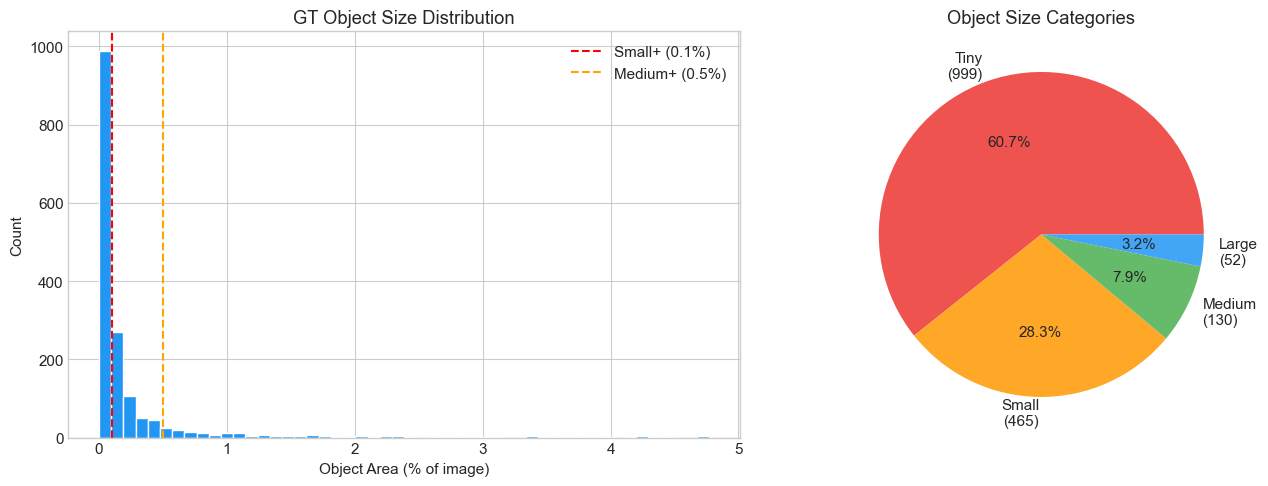

In [22]:
areas=[b['area'] for item in dataset for b in load_gt(item['label'])]
tiny=sum(1 for a in areas if a<0.001); small=sum(1 for a in areas if 0.001<=a<0.005)
med=sum(1 for a in areas if 0.005<=a<0.02); big=sum(1 for a in areas if a>=0.02)
print(f'Total: {len(areas)} | Tiny: {tiny} ({100*tiny/len(areas):.1f}%) | Small: {small} ({100*small/len(areas):.1f}%) | Medium: {med} ({100*med/len(areas):.1f}%) | Large: {big} ({100*big/len(areas):.1f}%)')

fig,(a1,a2)=plt.subplots(1,2,figsize=(14,5))
a1.hist([a*100 for a in areas if a<0.05],bins=50,color='#2196F3',edgecolor='white')
a1.axvline(x=0.1,color='red',linestyle='--',label='Small+ (0.1%)'); a1.axvline(x=0.5,color='orange',linestyle='--',label='Medium+ (0.5%)')
a1.set_xlabel('Object Area (% of image)'); a1.set_ylabel('Count'); a1.set_title('GT Object Size Distribution'); a1.legend()
a2.pie([tiny,small,med,big],labels=[f'Tiny\n({tiny})',f'Small\n({small})',f'Medium\n({med})',f'Large\n({big})'],colors=['#ef5350','#FFA726','#66BB6A','#42A5F5'],autopct='%1.1f%%')
a2.set_title('Object Size Categories')
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/rq1_size_distribution.png',dpi=150,bbox_inches='tight'); plt.show()

## 6. Run All Three Evaluations

In [23]:
t0=time.time()
r_all=evaluate(model,dataset,0.0,'All objects')
r_sm=evaluate(model,dataset,0.001,'Small+ (≥0.1%)')
r_md=evaluate(model,dataset,0.005,'Medium+ (≥0.5%)')
print(f'\nTotal: {time.time()-t0:.0f}s')


  Evaluating: All objects
    [40/131]
    [80/131]
    [120/131]
  Done. P=0.724 R=0.199 F1=0.313 mAP=0.150

  Evaluating: Small+ (≥0.1%)
    [40/131]
    [80/131]
    [120/131]
  Done. P=0.574 R=0.402 F1=0.473 mAP=0.233

  Evaluating: Medium+ (≥0.5%)
    [40/131]
    [80/131]
    [120/131]
  Done. P=0.232 R=0.577 F1=0.331 mAP=0.329

Total: 43s


## 7. Size Comparison Chart

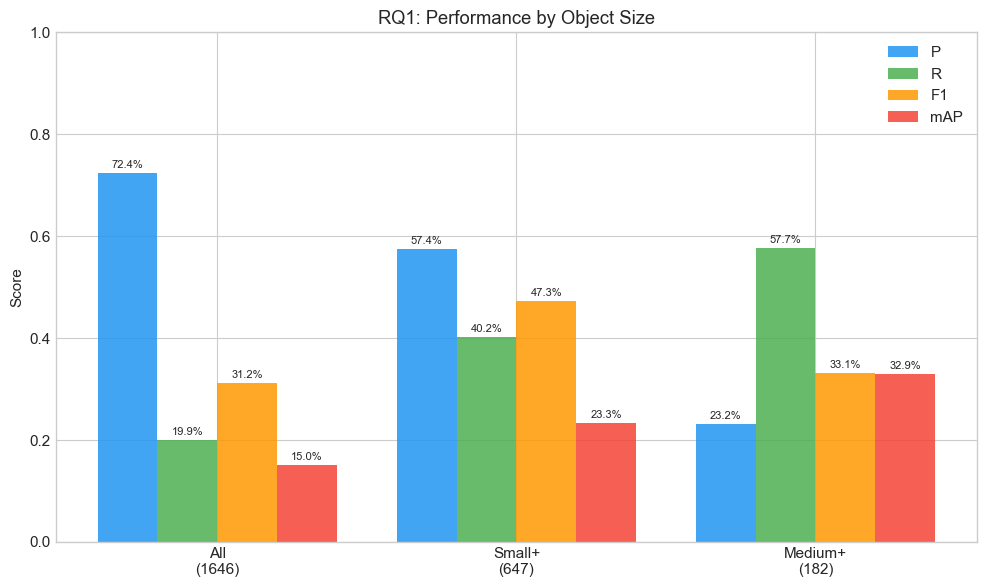

In [24]:
fig,ax=plt.subplots(figsize=(10,6))
lb=['All\n('+str(r_all['overall']['gt'])+')','Small+\n('+str(r_sm['overall']['gt'])+')','Medium+\n('+str(r_md['overall']['gt'])+')']
ms=['P','R','F1','mAP']; x=np.arange(3); w=0.2; cols=['#2196F3','#4CAF50','#FF9800','#F44336']
for i,m in enumerate(ms):
    vals=[r_all['overall'][m],r_sm['overall'][m],r_md['overall'][m]]
    bars=ax.bar(x+i*w,vals,w,label=m,color=cols[i],alpha=0.85)
    for bar,v in zip(bars,vals): ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,f'{v:.1%}',ha='center',fontsize=8)
ax.set_xticks(x+w*1.5); ax.set_xticklabels(lb); ax.set_ylabel('Score'); ax.set_title('RQ1: Performance by Object Size'); ax.legend(); ax.set_ylim(0,1)
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/rq1_size_comparison.png',dpi=150,bbox_inches='tight'); plt.show()

## 8. Per-Class Results (Small+)

Traffic light    P=14.3% R=2.0% F1=3.5% AP=4.5%
Bus              P=9.8% R=30.8% F1=14.8% AP=18.8%
Car              P=70.5% R=44.1% F1=54.3% AP=41.8%
Person           P=51.8% R=47.5% F1=49.6% AP=40.9%
Truck            P=6.2% R=14.3% F1=8.7% AP=10.6%
OVERALL          P=57.4% R=40.2% F1=47.3% mAP=23.3%


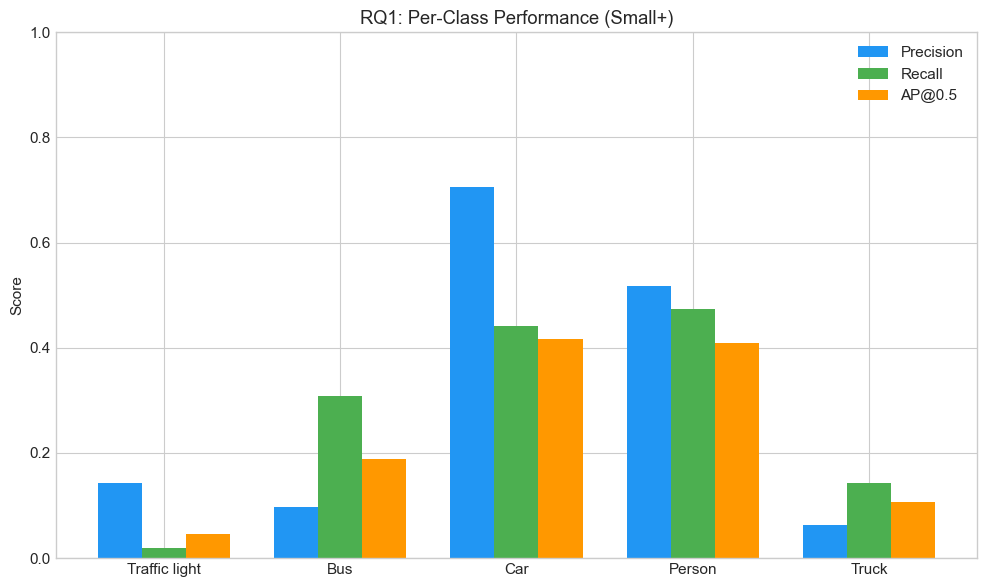

In [25]:
for r in r_sm['per_class']: print(f'{r["class"]:<16s} P={r["P"]:.1%} R={r["R"]:.1%} F1={r["F1"]:.1%} AP={r["AP"]:.1%}')
print(f'{"OVERALL":<16s} P={r_sm["overall"]["P"]:.1%} R={r_sm["overall"]["R"]:.1%} F1={r_sm["overall"]["F1"]:.1%} mAP={r_sm["overall"]["mAP"]:.1%}')

fig,ax=plt.subplots(figsize=(10,6))
cn=[r['class'] for r in r_sm['per_class']]; x=np.arange(len(cn)); w=0.25
ax.bar(x-w,[r['P'] for r in r_sm['per_class']],w,label='Precision',color='#2196F3')
ax.bar(x,[r['R'] for r in r_sm['per_class']],w,label='Recall',color='#4CAF50')
ax.bar(x+w,[r['AP'] for r in r_sm['per_class']],w,label='AP@0.5',color='#FF9800')
ax.set_xticks(x); ax.set_xticklabels(cn); ax.set_ylabel('Score'); ax.set_title('RQ1: Per-Class Performance (Small+)'); ax.legend(); ax.set_ylim(0,1)
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/rq1_per_class.png',dpi=150,bbox_inches='tight'); plt.show()

## 9. Confidence Analysis

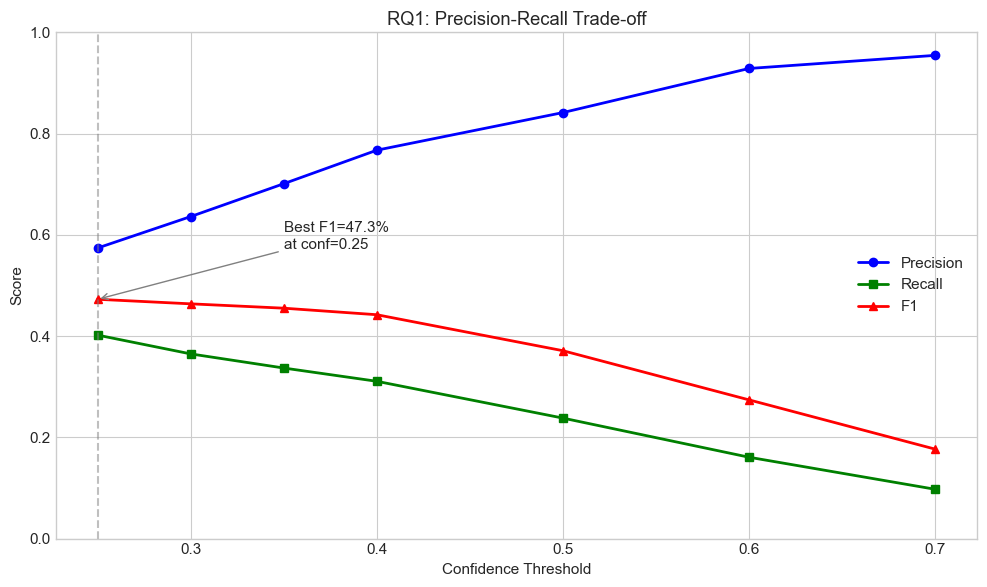

In [26]:
cd=r_sm['conf']; th=[c['thr'] for c in cd]
fig,ax=plt.subplots(figsize=(10,6))
ax.plot(th,[c['P'] for c in cd],'b-o',label='Precision',lw=2); ax.plot(th,[c['R'] for c in cd],'g-s',label='Recall',lw=2); ax.plot(th,[c['F1'] for c in cd],'r-^',label='F1',lw=2)
bf=max(cd,key=lambda x:x['F1']); ax.axvline(x=bf['thr'],color='gray',ls='--',alpha=0.5)
ax.annotate(f'Best F1={bf["F1"]:.1%}\nat conf={bf["thr"]}',xy=(bf['thr'],bf['F1']),xytext=(bf['thr']+0.1,bf['F1']+0.1),arrowprops=dict(arrowstyle='->',color='gray'))
ax.set_xlabel('Confidence Threshold'); ax.set_ylabel('Score'); ax.set_title('RQ1: Precision-Recall Trade-off'); ax.legend(); ax.set_ylim(0,1)
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/rq1_confidence.png',dpi=150,bbox_inches='tight'); plt.show()

## 10. Camera Ranking

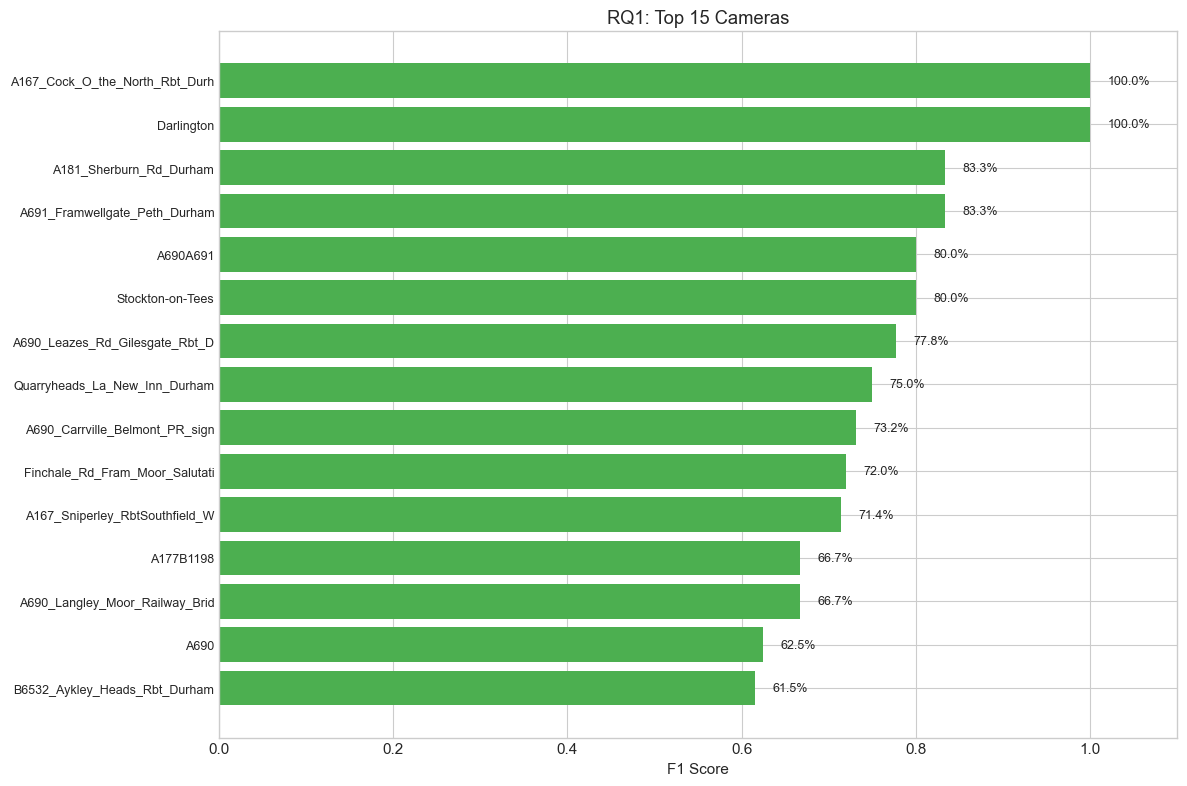

In [27]:
cams=sorted([c for c in r_sm['per_camera'] if (c['TP']+c['FN'])>0],key=lambda x:x['F1'],reverse=True)
fig,ax=plt.subplots(figsize=(12,8)); t15=cams[:15]; y=np.arange(len(t15))
ax.barh(y,[c['F1'] for c in t15],color='#4CAF50')
ax.set_yticks(y); ax.set_yticklabels([c['camera'][:30] for c in t15],fontsize=9)
for i,c in enumerate(t15): ax.text(c['F1']+0.02,i,f'{c["F1"]:.1%}',va='center',fontsize=9)
ax.set_xlabel('F1 Score'); ax.set_title('RQ1: Top 15 Cameras'); ax.set_xlim(0,1.1); ax.invert_yaxis()
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/rq1_cameras.png',dpi=150,bbox_inches='tight'); plt.show()

## 11. Save CSVs

In [28]:
with open(f'{RESULTS_DIR}/rq1_size_comparison.csv','w',newline='') as f:
    w=csv.DictWriter(f,fieldnames=r_all['overall'].keys()); w.writeheader()
    for r in [r_all,r_sm,r_md]: w.writerow(r['overall'])
with open(f'{RESULTS_DIR}/rq1_per_class.csv','w',newline='') as f:
    w=csv.DictWriter(f,fieldnames=r_sm['per_class'][0].keys()); w.writeheader(); w.writerows(r_sm['per_class'])
with open(f'{RESULTS_DIR}/rq1_per_camera.csv','w',newline='') as f:
    w=csv.DictWriter(f,fieldnames=r_sm['per_camera'][0].keys()); w.writeheader(); w.writerows(r_sm['per_camera'])
print('All RQ1 results saved.')

All RQ1 results saved.


## RQ1 Complete ✅
Baseline results established. Proceed to **RQ2_Finetune_Comparison.ipynb** for fine-tuning and before/after comparison.